<h1>Homework 1: Data Curation and Classification</h1>

<h2>A. Retrieve the Data</h2>

In [1]:
import pandas as pd

# get the data
data = pd.read_csv('./data/hwc.csv')
data.head()

,P_NAME,P_DETECTION,P_DISCOVERY_FACILITY,P_YEAR,P_UPDATE,P_MASS,P_MASS_ERROR_MIN,P_MASS_ERROR_MAX,P_MASS_LIMIT,P_MASS_ORIGIN,...,S_ABIO_ZONE,S_TIDAL_LOCK,P_HABZONE_OPT,P_HABZONE_CON,P_TYPE_TEMP,P_HABITABLE,P_ESI,S_CONSTELLATION,S_CONSTELLATION_ABR,S_CONSTELLATION_ENG
0,OGLE-2016-BLG-1227L b,Microlensing,OGLE,2020,2020-04-02,250.00,-120.0,413.0,0,Mass,...,NaN,0.214133,0,0,NaN,0,NaN,Scorpius,Sco,Scorpion
1,Kepler-276 c,Transit,Kepler,2013,2018-09-25,16.60,-3.6,4.4,0,Mass,...,2.097783,0.316980,0,0,Hot,0,0.272032,Cygnus,Cyg,Swan
2,Kepler-829 b,Transit,Kepler,2016,2019-04-16,5.10,NaN,NaN,0,M-R relationship,...,1.756317,0.459559,0,0,Hot,0,0.254763,Lyra,Lyr,Lyre
3,K2-283 b,Transit,K2,2018,2019-09-05,12.20,NaN,NaN,0,M-R relationship,...,0.568374,0.443760,0,0,Hot,0,0.193906,Pisces,Psc,Fishes
4,Kepler-477 b,Transit,Kepler,2016,2019-04-16,4.94,NaN,NaN,0,M-R relationship,...,0.768502,0.386150,0,0,Hot,0,0.276721,Lyra,Lyr,Lyre


In [2]:
# print out the column names in groups of 10
for i in range(len(data.columns) // 10):
    print(data.columns[i*10:(i+1)*10])

Index(['P_NAME', 'P_DETECTION', 'P_DISCOVERY_FACILITY', 'P_YEAR', 'P_UPDATE',
       'P_MASS', 'P_MASS_ERROR_MIN', 'P_MASS_ERROR_MAX', 'P_MASS_LIMIT',
       'P_MASS_ORIGIN'],
      dtype='str')
Index(['P_RADIUS', 'P_RADIUS_ERROR_MIN', 'P_RADIUS_ERROR_MAX',
       'P_RADIUS_LIMIT', 'P_PERIOD', 'P_PERIOD_ERROR_MIN',
       'P_PERIOD_ERROR_MAX', 'P_PERIOD_LIMIT', 'P_SEMI_MAJOR_AXIS',
       'P_SEMI_MAJOR_AXIS_ERROR_MIN'],
      dtype='str')
Index(['P_SEMI_MAJOR_AXIS_ERROR_MAX', 'P_SEMI_MAJOR_AXIS_LIMIT',
       'P_ECCENTRICITY', 'P_ECCENTRICITY_ERROR_MIN',
       'P_ECCENTRICITY_ERROR_MAX', 'P_ECCENTRICITY_LIMIT', 'P_INCLINATION',
       'P_INCLINATION_ERROR_MIN', 'P_INCLINATION_ERROR_MAX',
       'P_INCLINATION_LIMIT'],
      dtype='str')
Index(['P_OMEGA', 'P_OMEGA_ERROR_MIN', 'P_OMEGA_ERROR_MAX', 'P_OMEGA_LIMIT',
       'S_NAME', 'S_NAME_HD', 'S_NAME_HIP', 'S_TYPE', 'S_RA', 'S_DEC'],
      dtype='str')
Index(['S_RA_STR', 'S_DEC_STR', 'S_MAG', 'S_MAG_ERROR_MIN', 'S_MAG_ERROR_MAX',
     

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5599 entries, 0 to 5598
Columns: 118 entries, P_NAME to S_CONSTELLATION_ENG
dtypes: float64(81), int64(18), str(19)
memory usage: 5.0 MB


In [4]:
# find how many rows have missing values
missing_rows = data.isnull().any(axis=1).sum()
missing_rows

np.int64(5586)

There are a total of 5599 data points. 5586 of them contain at least one missing value.

Additionally, the features included contain information on both the exoplanet and its host star. Exoplanet features contain "P_{feature name}", while host star features contain "S_{feature name}". There is a lot of information on the exoplanet such as its surface temperature (P_TEMP_SURF), mass (P_MASS), orbital radius and period (P_PERIOD and P_SEMI_MAJOR_AXIS), and many more. For its host star, there is also information on its temperature (S_TEMPERATURE), spectral classification (S_TYPE), distance from earth (S_DISTANCE), and many more. 

It is also worthwhile to mention that some of the values contain a error min, error max, and limit. These are uncertainty measures. 

I believe values such as the exoplanets' surface temperature (to test for Goldilocks zone), radius, mass, orbital radius/period, and possibly distance from earth (along with the host stars' distance from earth to calculate distance from each other) will be very important for deciding if the exoplanet is habitable. S_HZ_OPT_MIN / S_HZ_OPT_MAX helps gives the habitable zone that can help figure out where liquid water can exist. Values like S_TEMPERATURE / S_LUMINOSITY can also help with the habitable zone. 

<h2> B: Explore the Data </h2>

In [5]:
# Check for any imbalance in the target variable
data['P_HABITABLE'].value_counts()

P_HABITABLE
0    5529
2      41
1      29
Name: count, dtype: int64

There is a class imbalance with most of the datapoints being with P_HABITABLE=0 (where 0 is 'Not Habitable'). So, further techniques will have to be used (stratified samples and F1 scores).

In [6]:
# check for value counts for categorical variables
columns = ['P_TYPE', 'S_TYPE', 'P_DETECTION']

for column in columns:
    print(f"{column} value counts:\n")
    print(data[column].value_counts())
    print("Null value counts: ", data[column].isnull().sum())
    print("\n")

P_TYPE value counts:

P_TYPE
Jovian         1706
Neptunian      1401
Superterran    1347
Terran         1060
Subterran        69
Miniterran        9
Name: count, dtype: int64
Null value counts:  7


S_TYPE value counts:

S_TYPE
G0 V        64
K0          60
G5 V        56
M0 V        56
G5          54
            ..
M9-L1        1
K5/M0V       1
M2.5 III     1
M3.5 Ve      1
G0 VI        1
Name: count, Length: 293, dtype: int64
Null value counts:  3578


P_DETECTION value counts:

P_DETECTION
Transit                          4166
Radial Velocity                  1087
Microlensing                      210
Imaging                            68
Transit Timing Variations          29
Eclipse Timing Variations          17
Orbital Brightness Modulation       9
Pulsar Timing                       7
Astrometry                          3
Pulsation Timing Variations         2
Disk Kinematics                     1
Name: count, dtype: int64
Null value counts:  0




S_TYPE has so many missing values so I don't think I will analyze further.

In [7]:
# check for how P_DETECTION relates to P_HABITABLE
pd.crosstab(data['P_DETECTION'], data['P_HABITABLE'], margins=True, normalize='index')

P_HABITABLE,0,1,2
P_DETECTION,,,
Astrometry,1.000000,0.000000,0.000000
Disk Kinematics,1.000000,0.000000,0.000000
Eclipse Timing Variations,1.000000,0.000000,0.000000
Imaging,1.000000,0.000000,0.000000
Microlensing,1.000000,0.000000,0.000000
Orbital Brightness Modulation,1.000000,0.000000,0.000000
Pulsar Timing,1.000000,0.000000,0.000000
Pulsation Timing Variations,1.000000,0.000000,0.000000
Radial Velocity,0.973321,0.011040,0.015639


Only Radial Velocity and Transit techniques were used to identify habitable exoplanets (whether optimistically or conservatively).

In [8]:
# check for stats and null values for numerical columns that could relate to habitability
column_names = [
    'P_SEMI_MAJOR_AXIS',
    'P_SEMI_MAJOR_AXIS_ERROR_MIN',
    'P_SEMI_MAJOR_AXIS_ERROR_MAX',
    'P_TEMP_SURF',
    'P_TEMP_EQUIL',
    'S_TEMPERATURE',
    'S_TEMPERATURE_ERROR_MIN',
    'S_TEMPERATURE_ERROR_MAX',
    'P_RADIUS',
    'P_RADIUS_ERROR_MIN',
    'P_RADIUS_ERROR_MAX',
    'P_MASS',
    'P_MASS_ERROR_MIN',
    'P_MASS_ERROR_MAX',
    'S_HZ_OPT_MAX',
    'S_HZ_OPT_MIN',
    'S_HZ_CON_MAX',
    'S_HZ_CON_MIN',
    'S_HZ_CON0_MAX',
    'S_HZ_CON0_MIN',
    'S_HZ_CON1_MAX',
    'S_HZ_CON1_MIN',
    'S_LUMINOSITY',
    'P_ECCENTRICITY',
    'P_ECCENTRICITY_ERROR_MIN',
    'P_ECCENTRICITY_ERROR_MAX',
    'P_FLUX',
    'P_PERIOD',
    'P_PERIOD_ERROR_MIN',
    'P_PERIOD_ERROR_MAX'
]

for column in column_names:
    print(f"{column}:\n")
    print("Null Values: ", data[column].isnull().sum())
    print(data[column].describe())
    print()

P_SEMI_MAJOR_AXIS:

Null Values:  4
count    5595.000000
mean        6.307151
std       130.676333
min         0.004400
25%         0.052750
50%         0.102100
75%         0.284600
max      7506.000000
Name: P_SEMI_MAJOR_AXIS, dtype: float64

P_SEMI_MAJOR_AXIS_ERROR_MIN:

Null Values:  2902
count    2697.000000
mean       -1.181542
std        40.025707
min     -2060.000000
25%        -0.040000
50%        -0.002900
75%        -0.000880
max         0.000000
Name: P_SEMI_MAJOR_AXIS_ERROR_MIN, dtype: float64

P_SEMI_MAJOR_AXIS_ERROR_MAX:

Null Values:  2902
count    2697.000000
mean        2.392528
std       100.364179
min         0.000000
25%         0.000830
50%         0.002800
75%         0.038000
max      5205.000000
Name: P_SEMI_MAJOR_AXIS_ERROR_MAX, dtype: float64

P_TEMP_SURF:

Null Values:  3158
count    2441.000000
mean      971.994023
std       487.382871
min       130.661650
25%       638.352490
50%       908.701120
75%      1204.326300
max      8125.496300
Name: P_TEMP_SURF,

P_TEMP_SURF contains a lot of missing/null values so it may better to use P_TEMP_EQUIL over P_TEMP_SURF, which has much less missing values. Also, most of the features contain an outlier shown with their max values being way ahead of the percentile values. These columns have very spread out data: P_MASS, P_SEMI_MAJOR_AXIS, S_HZ_OPT_MAX, S_HZ_CON_MAX, S_HZ_CON_MIN (CON0 and CON1 min and max as well), and S_LUMINOSITY. Because of these outliers and spread out data, it will be best to use models best equipped for them and/or use normalizing and scaling techniques. Additionally, S_HZ_CON_MAX and S_HZ_CON_MAX's statistics is very similar to the 'CON0' and 'CON1' versions, so best to keep just one, which will be the 'CON' version. 

Also, for '_ERROR_MAX' and '_ERROR_MIN' features, most of them have missing values, so either some techniques didn't add in uncertainty values or they weren't reported. 

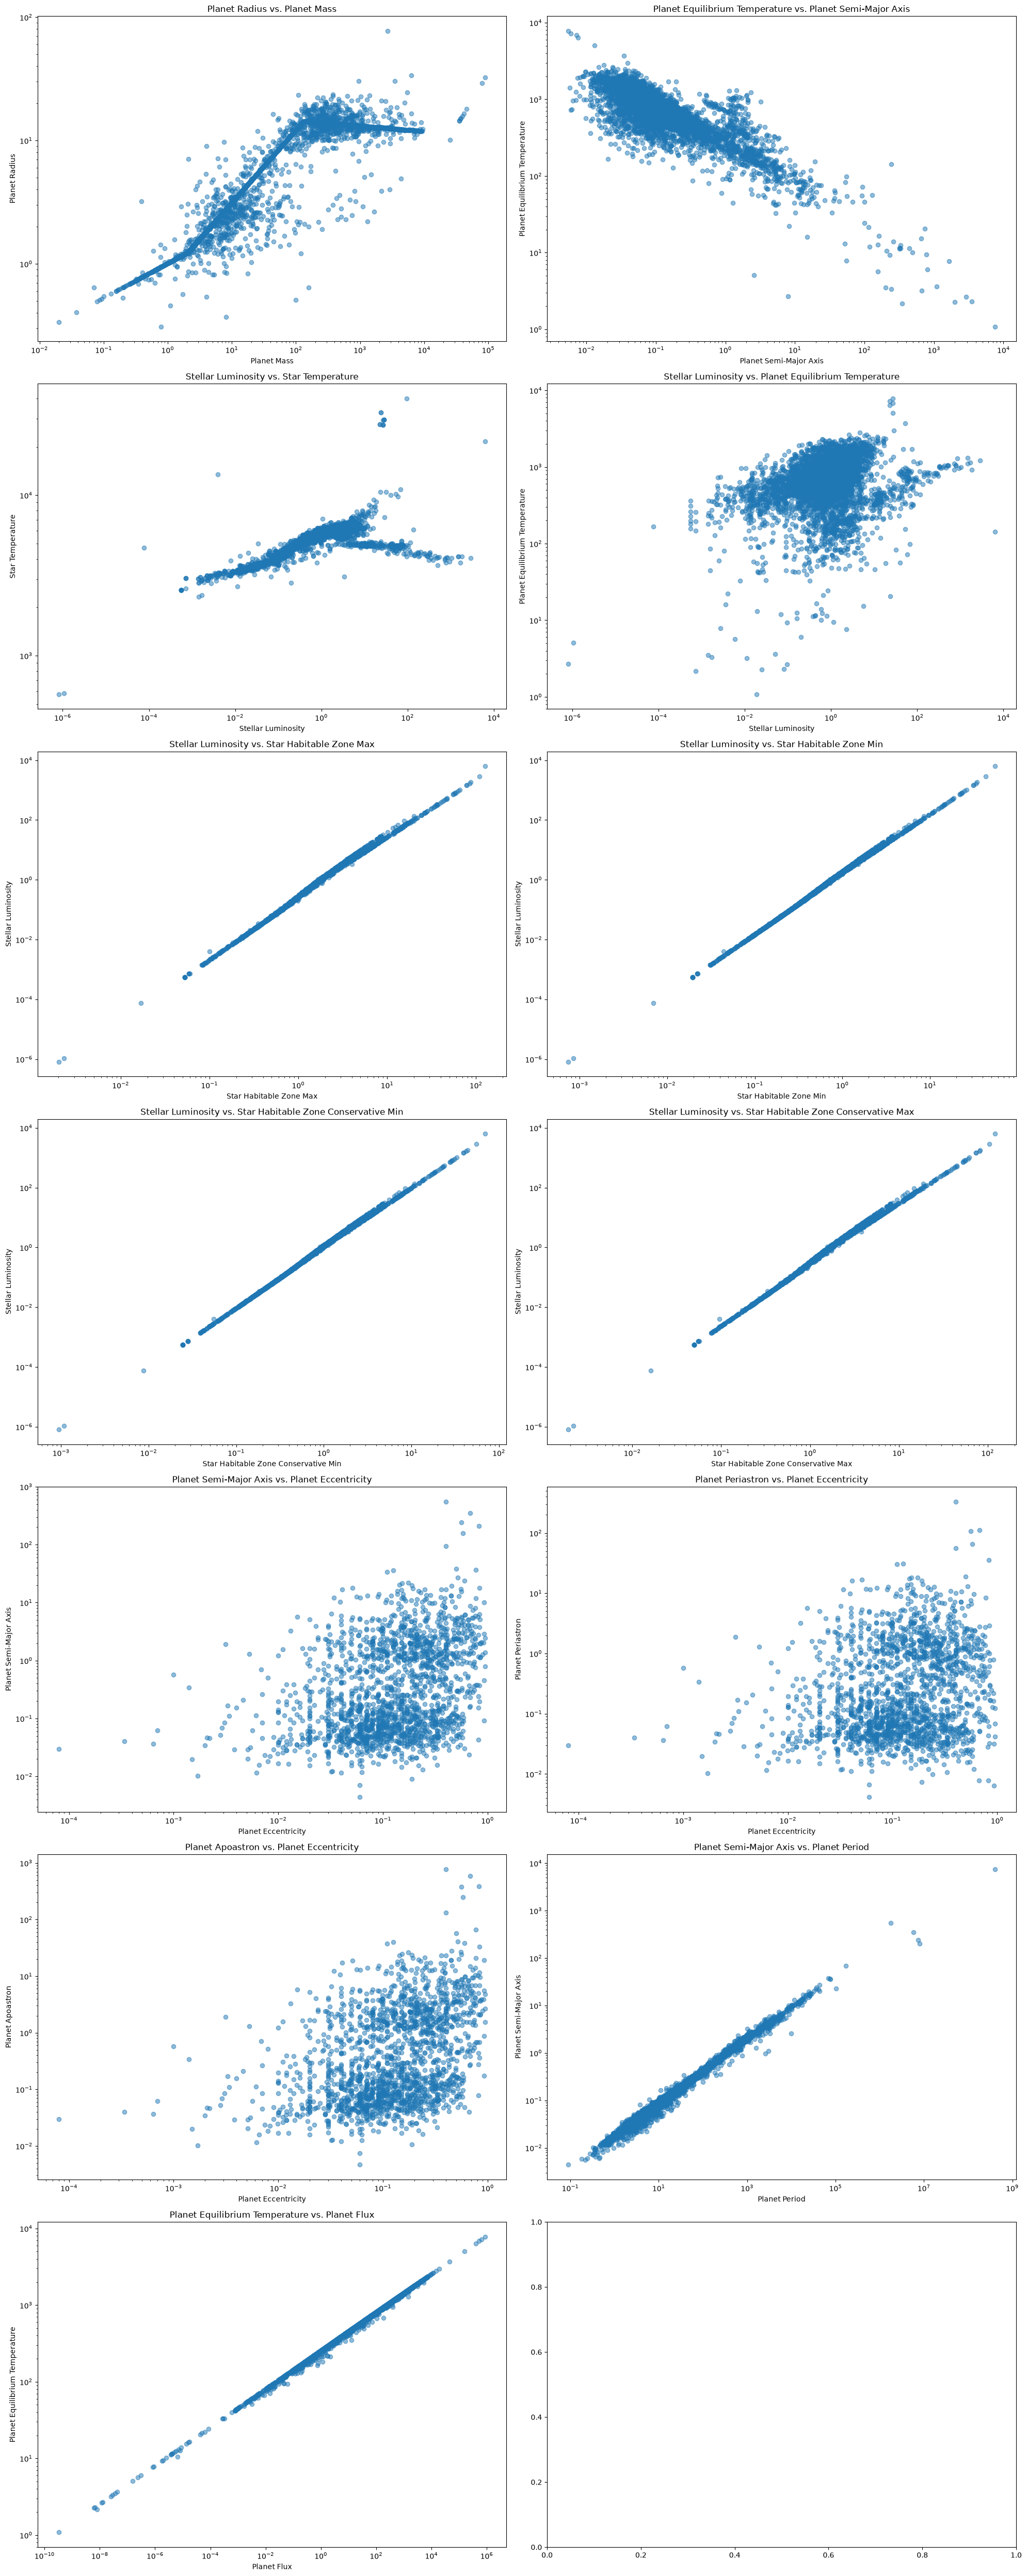

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(7, 2, figsize=(20, 50))

# Create scatter plots for the specified pairs of columns that could relate to habitability
plots = [
    ('P_MASS', 'P_RADIUS', 'Planet Mass', 'Planet Radius', 'Planet Radius vs. Planet Mass'),
    ('P_SEMI_MAJOR_AXIS', 'P_TEMP_EQUIL', 'Planet Semi-Major Axis', 'Planet Equilibrium Temperature', 'Planet Equilibrium Temperature vs. Planet Semi-Major Axis'),
    ('S_LUMINOSITY', 'S_TEMPERATURE', 'Stellar Luminosity', 'Star Temperature', 'Stellar Luminosity vs. Star Temperature'),
    ('S_LUMINOSITY', 'P_TEMP_EQUIL', 'Stellar Luminosity', 'Planet Equilibrium Temperature', 'Stellar Luminosity vs. Planet Equilibrium Temperature'),
    ('S_HZ_OPT_MAX', 'S_LUMINOSITY', 'Star Habitable Zone Max', 'Stellar Luminosity', 'Stellar Luminosity vs. Star Habitable Zone Max'),
    ('S_HZ_OPT_MIN', 'S_LUMINOSITY', 'Star Habitable Zone Min', 'Stellar Luminosity', 'Stellar Luminosity vs. Star Habitable Zone Min'),
    ('S_HZ_CON_MIN', 'S_LUMINOSITY', 'Star Habitable Zone Conservative Min', 'Stellar Luminosity', 'Stellar Luminosity vs. Star Habitable Zone Conservative Min'),
    ('S_HZ_CON_MAX', 'S_LUMINOSITY', 'Star Habitable Zone Conservative Max', 'Stellar Luminosity', 'Stellar Luminosity vs. Star Habitable Zone Conservative Max'),
    ('P_ECCENTRICITY', 'P_SEMI_MAJOR_AXIS', 'Planet Eccentricity', 'Planet Semi-Major Axis', 'Planet Semi-Major Axis vs. Planet Eccentricity'),
    ('P_ECCENTRICITY', 'P_PERIASTRON', 'Planet Eccentricity', 'Planet Periastron', 'Planet Periastron vs. Planet Eccentricity'),
    ('P_ECCENTRICITY', 'P_APASTRON', 'Planet Eccentricity', 'Planet Apoastron', 'Planet Apoastron vs. Planet Eccentricity'),
    ('P_PERIOD', 'P_SEMI_MAJOR_AXIS', 'Planet Period', 'Planet Semi-Major Axis', 'Planet Semi-Major Axis vs. Planet Period'),
    ('P_FLUX', 'P_TEMP_EQUIL', 'Planet Flux', 'Planet Equilibrium Temperature', 'Planet Equilibrium Temperature vs. Planet Flux'),
]   

# go through each axis and plot the corresponding scatter plot
for axis, (x_column, y_column, x_label, y_label, title) in zip(axes.flat, plots):
    axis.scatter(data[x_column], data[y_column], alpha=0.5)
    axis.set_xlabel(x_label)
    axis.set_xscale('log')
    axis.set_ylabel(y_label)
    axis.set_yscale('log')
    axis.set_title(title)

fig.tight_layout()
plt.show()

Other than the scatter plots with P_ECCENTRICITY, each scatter plot shows a relationship between the two features. Here are the observations:

- As the exoplanet's mass grows, the exoplanet's radii grows.
- As orbit radius increases, the equilibrium temperature of the exoplanet decreases.
- Not as steep, but as stellar luminosity grows, the star's temperature grows.
- Not as visible, but you can still see equilibrium temperature of exoplanets grow as the stellar luminosity grows.
- As star luminosity grows, all of S_HZ_OPT_MAX, S_HZ_OPT_MIN, S_HZ_CON_MAX, S_HZ_CON_MIN grow.
- As orbit radius increases, exoplanet's orbital period increases.
- P_ECCENTRICITY has no clear relationship with orbital radius, exoplanet periastron, and exoplanet apastron.
- As P_FLUX increases, equilibrium temperature of exoplanet increases.

<h1>

Okay, now I will look how uncertainty affects some of these features for the ones that include '_ERROR_MIN', '_ERROR_MAX', and '_LIMIT'.

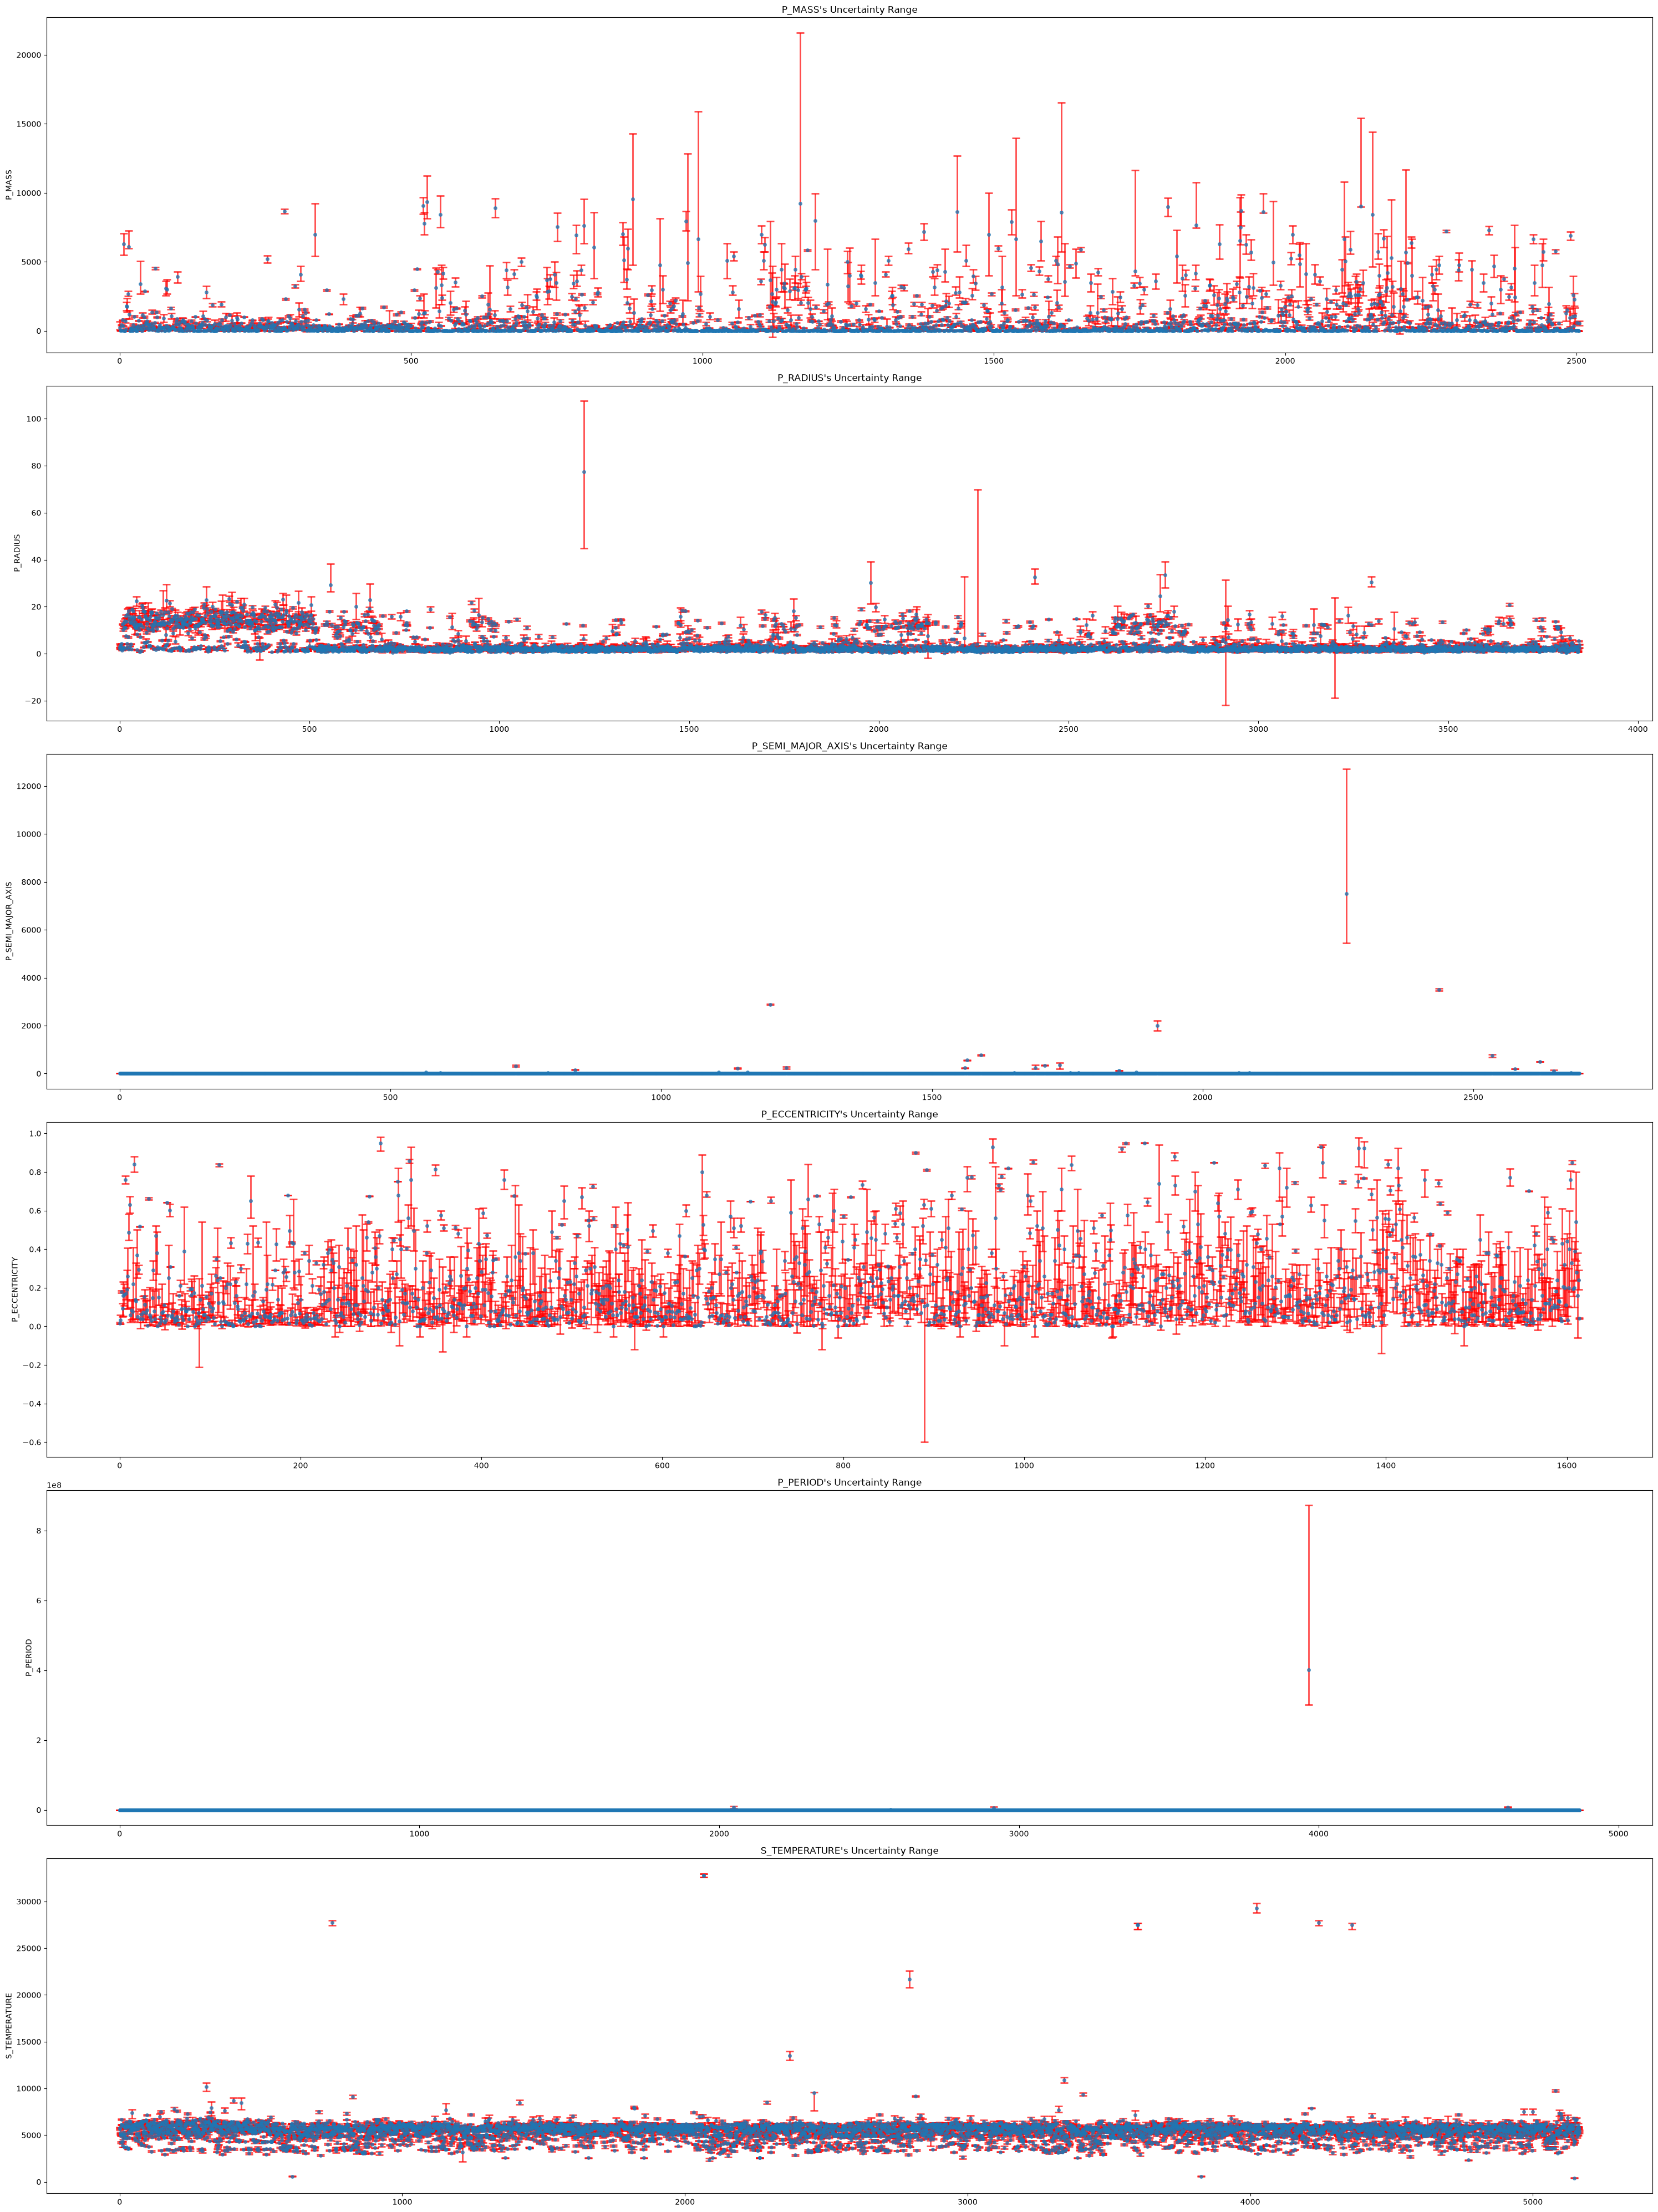

In [10]:
fig, axes = plt.subplots(6, 1, figsize=(30, 40))

columns = [
    'P_MASS', 
    'P_RADIUS', 
    'P_SEMI_MAJOR_AXIS', 
    'P_ECCENTRICITY', 
    'P_PERIOD',
    'S_TEMPERATURE']

# create an error bar for each feature that has uncertainty values computed
for axis, column in zip(axes.flat, columns):
    df = data.dropna(subset=[column, f'{column}_ERROR_MIN', f'{column}_ERROR_MAX'])

    axis.errorbar(
        x=range(len(df)),        
        y=df[column],
        yerr=[df[f'{column}_ERROR_MIN'].abs(), df[f'{column}_ERROR_MAX'].abs()],
        fmt='o', ecolor='red', elinewidth=2, capsize=5, capthick=2,
        markersize=4, alpha=0.7
    )
    axis.set_ylabel(column)
    axis.set_title(f'{column}\'s Uncertainty Range')

fig.tight_layout()
plt.show()

- For P_ECCENTRICITY, it seems like there is a lot of uncertainty with the values. Could point to the fact that it didn't have much correlation in the scatter plots.
- For P_PERIOD, the ranges are very tight except for one value. Same for P_SEMI_MAJOR_AXIS.
- The ranges are somewhat tight for S_TEMPERATURE.
- The ranges vary for P_MASS and P_RADIUS. 

This may affect model confidence, but for exploratory classification, it is not needed to do error propagation or Monte Carlo sampling. It is best to fix this through better classification methods. However, we will be testing 4 so some may be affected and some may not be affected.

So, by analyzing the data, we can see that there are uncertainty issues, outliers, missing values, class imbalance, and a dynamic range. These are important to take care of because they directly affect how reliable and generalizable a classification model will be.

- Uncertainty in measurements means some feature values may not reflect the true physical quantity, which can mislead the model into learning patterns based on noise rather than real relationships.

- Outliers can distort statistical summaries and disproportionately influence distance-based or linear models, leading to skewed decision boundaries.

- Missing values, if not properly imputed or accounted for, can reduce the effective sample size or introduce bias if the missingness isn't random.

- Class imbalance can cause the model to favor the majority class, achieving high accuracy while failing to correctly identify the minority, which the class that we are trying to identify (Habitable optimistically or conservatively).

- Dynamic range differences across features can cause scale-sensitive models (like KNN, SVM, or neural networks) to weight large-magnitude features (temperature features) more heavily than small-magnitude ones (distance features).

<h2> C: Prepare the dataset for classification </h2>

I will use the following features:

- P_MASS: the mass of the exoplanet.
- P_RADIUS: the radius of the exoplanet.
- P_SEMI_MAJOR_AXIS: the orbital radius of the exoplanet.
- P_DETECTION: the technique that was done to identify the exoplanet and measure and estimate its values.
- P_TEMP_EQUIL: the equilibrium temperature of the exoplanet.
- P_FLUX: the exoplanet's flux value (how much of its host star's light is hitting it)
- P_PERIOD: the orbital period of the exoplanet (how long it takes to revolve around its host star)
- S_TEMPERATURE: the temperature of the host star
- S_LUMINOSITY: the brightness of the host star
- S_HZ_OPT_MAX: the max optimistic distance value of the habitable zone (zone where liquid water could exist)
- S_HZ_OPT_MIN: the min optimistic distance value of the habitable zone (zone where liquid water could exist)
- S_HZ_CON_MAX: the max conservative distance value of the habitable zone (zone where liquid water could exist)
- S_HZ_CON_MIN: the max conservative distance value of the habitable zone (zone where liquid water could exist)

First, I will reiterate that the problem of uncertainty will not be fixed because of the type of problem being classification. If I was going to create new features with the existing features, then I would have to take care of the uncertainty values, but I will not be doing that for this project. Also, certain methods like regression and bayesian NN can handle uncertainty, but we will see if KNN, random forest, MLP, or XGBoost will handle it well.

outliers and dynamic range (scaling/normalization)
class imbalance (stratified sampling -> connected but doesn't solve)

In [11]:
# only grab the columns of the features to be used and make a dataframe copy
columns = [
    'P_MASS',
    'P_RADIUS',
    'P_SEMI_MAJOR_AXIS',
    'P_DETECTION',
    'P_TEMP_EQUIL',
    'P_FLUX',
    'P_PERIOD',
    'S_TEMPERATURE',
    'S_LUMINOSITY',
    'S_HZ_OPT_MAX',
    'S_HZ_OPT_MIN',
    'S_HZ_CON_MAX',
    'S_HZ_CON_MIN'
]
chosen_data = data[columns].copy()
chosen_data.head()

,P_MASS,P_RADIUS,P_SEMI_MAJOR_AXIS,P_DETECTION,P_TEMP_EQUIL,P_FLUX,P_PERIOD,S_TEMPERATURE,S_LUMINOSITY,S_HZ_OPT_MAX,S_HZ_OPT_MIN,S_HZ_CON_MAX,S_HZ_CON_MIN
0,250.00,13.90,3.4000,Microlensing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,16.60,2.90,0.1994,Transit,541.98483,20.490365,31.884000,5779.0,0.814704,1.595742,0.677337,1.512908,0.857931
2,5.10,2.11,0.0678,Transit,1001.11710,238.528680,6.883376,5698.0,1.096478,1.864342,0.789603,1.767566,1.000132
3,12.20,3.52,0.0291,Transit,1104.46820,353.357260,1.921036,5060.0,0.299226,1.030473,0.427216,0.976981,0.541131
4,4.94,2.07,0.0911,Transit,681.30334,51.163853,11.119907,5240.0,0.424620,1.208168,0.504264,1.145452,0.638721


In [12]:
chosen_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5599 entries, 0 to 5598
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   P_MASS             5592 non-null   float64
 1   P_RADIUS           5592 non-null   float64
 2   P_SEMI_MAJOR_AXIS  5595 non-null   float64
 3   P_DETECTION        5599 non-null   str    
 4   P_TEMP_EQUIL       5365 non-null   float64
 5   P_FLUX             5365 non-null   float64
 6   P_PERIOD           5350 non-null   float64
 7   S_TEMPERATURE      5380 non-null   float64
 8   S_LUMINOSITY       5366 non-null   float64
 9   S_HZ_OPT_MAX       5366 non-null   float64
 10  S_HZ_OPT_MIN       5366 non-null   float64
 11  S_HZ_CON_MAX       5366 non-null   float64
 12  S_HZ_CON_MIN       5366 non-null   float64
dtypes: float64(12), str(1)
memory usage: 568.8 KB


First, we have to do one-hot encoding for 'P_DETECTION' because it is a categorical feature. We need to transition it into a numerical feature. 

In [13]:
chosen_data['P_DETECTION'].value_counts()

P_DETECTION
Transit                          4166
Radial Velocity                  1087
Microlensing                      210
Imaging                            68
Transit Timing Variations          29
Eclipse Timing Variations          17
Orbital Brightness Modulation       9
Pulsar Timing                       7
Astrometry                          3
Pulsation Timing Variations         2
Disk Kinematics                     1
Name: count, dtype: int64

By looking at the value counts again, we can see that the counts are lopsided so the techniques outside the top 3 will have mostly 0's in their column when one-hot encoding is done. So, it is best to combine those as 'Other'.  

In [14]:
# Keep the top categories, group the rest as "Other"
top_categories = ['Transit', 'Radial Velocity', 'Microlensing']

chosen_data['P_DETECTION_GROUPED'] = chosen_data['P_DETECTION'].apply(
    lambda x: x if x in top_categories else 'Other'
)

# drop P_DETECTION
chosen_data.drop(columns='P_DETECTION', inplace=True)

# one-hot encode the grouped version
chosen_data_encoded = pd.get_dummies(chosen_data, columns=['P_DETECTION_GROUPED'], prefix='DETECTION')
chosen_data_encoded.head()

,P_MASS,P_RADIUS,P_SEMI_MAJOR_AXIS,P_TEMP_EQUIL,P_FLUX,P_PERIOD,S_TEMPERATURE,S_LUMINOSITY,S_HZ_OPT_MAX,S_HZ_OPT_MIN,S_HZ_CON_MAX,S_HZ_CON_MIN,DETECTION_Microlensing,DETECTION_Other,DETECTION_Radial Velocity,DETECTION_Transit
0,250.00,13.90,3.4000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,False
1,16.60,2.90,0.1994,541.98483,20.490365,31.884000,5779.0,0.814704,1.595742,0.677337,1.512908,0.857931,False,False,False,True
2,5.10,2.11,0.0678,1001.11710,238.528680,6.883376,5698.0,1.096478,1.864342,0.789603,1.767566,1.000132,False,False,False,True
3,12.20,3.52,0.0291,1104.46820,353.357260,1.921036,5060.0,0.299226,1.030473,0.427216,0.976981,0.541131,False,False,False,True
4,4.94,2.07,0.0911,681.30334,51.163853,11.119907,5240.0,0.424620,1.208168,0.504264,1.145452,0.638721,False,False,False,True


In [15]:
chosen_data_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 5599 entries, 0 to 5598
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   P_MASS                     5592 non-null   float64
 1   P_RADIUS                   5592 non-null   float64
 2   P_SEMI_MAJOR_AXIS          5595 non-null   float64
 3   P_TEMP_EQUIL               5365 non-null   float64
 4   P_FLUX                     5365 non-null   float64
 5   P_PERIOD                   5350 non-null   float64
 6   S_TEMPERATURE              5380 non-null   float64
 7   S_LUMINOSITY               5366 non-null   float64
 8   S_HZ_OPT_MAX               5366 non-null   float64
 9   S_HZ_OPT_MIN               5366 non-null   float64
 10  S_HZ_CON_MAX               5366 non-null   float64
 11  S_HZ_CON_MIN               5366 non-null   float64
 12  DETECTION_Microlensing     5599 non-null   bool   
 13  DETECTION_Other            5599 non-null   bool   
 14  DET

Now, I will deal with the missing values per feature. Lets look at the number of null values again.

In [16]:
# print out the number of null values per feature
chosen_data_encoded.isnull().sum()

P_MASS                         7
P_RADIUS                       7
P_SEMI_MAJOR_AXIS              4
P_TEMP_EQUIL                 234
P_FLUX                       234
P_PERIOD                     249
S_TEMPERATURE                219
S_LUMINOSITY                 233
S_HZ_OPT_MAX                 233
S_HZ_OPT_MIN                 233
S_HZ_CON_MAX                 233
S_HZ_CON_MIN                 233
DETECTION_Microlensing         0
DETECTION_Other                0
DETECTION_Radial Velocity      0
DETECTION_Transit              0
dtype: int64

Since there is a low percentage of null/missing values per feature, we don't have to use a complicated imputer. We can use a simple imputer. It is best to use median here because of the outliers that were identified earlier. 

In [17]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
chosen_data_encoded[chosen_data_encoded.columns] = imputer.fit_transform(chosen_data_encoded[chosen_data_encoded.columns])
chosen_data_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 5599 entries, 0 to 5598
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   P_MASS                     5599 non-null   float64
 1   P_RADIUS                   5599 non-null   float64
 2   P_SEMI_MAJOR_AXIS          5599 non-null   float64
 3   P_TEMP_EQUIL               5599 non-null   float64
 4   P_FLUX                     5599 non-null   float64
 5   P_PERIOD                   5599 non-null   float64
 6   S_TEMPERATURE              5599 non-null   float64
 7   S_LUMINOSITY               5599 non-null   float64
 8   S_HZ_OPT_MAX               5599 non-null   float64
 9   S_HZ_OPT_MIN               5599 non-null   float64
 10  S_HZ_CON_MAX               5599 non-null   float64
 11  S_HZ_CON_MIN               5599 non-null   float64
 12  DETECTION_Microlensing     5599 non-null   float64
 13  DETECTION_Other            5599 non-null   float64
 14  DET

In [18]:
chosen_data_encoded.head()

,P_MASS,P_RADIUS,P_SEMI_MAJOR_AXIS,P_TEMP_EQUIL,P_FLUX,P_PERIOD,S_TEMPERATURE,S_LUMINOSITY,S_HZ_OPT_MAX,S_HZ_OPT_MIN,S_HZ_CON_MAX,S_HZ_CON_MIN,DETECTION_Microlensing,DETECTION_Other,DETECTION_Radial Velocity,DETECTION_Transit
0,250.00,13.90,3.4000,727.30629,67.353048,11.569511,5555.0,0.859014,1.647249,0.698581,1.561742,0.884840,1.0,0.0,0.0,0.0
1,16.60,2.90,0.1994,541.98483,20.490365,31.884000,5779.0,0.814704,1.595742,0.677337,1.512908,0.857931,0.0,0.0,0.0,1.0
2,5.10,2.11,0.0678,1001.11710,238.528680,6.883376,5698.0,1.096478,1.864342,0.789603,1.767566,1.000132,0.0,0.0,0.0,1.0
3,12.20,3.52,0.0291,1104.46820,353.357260,1.921036,5060.0,0.299226,1.030473,0.427216,0.976981,0.541131,0.0,0.0,0.0,1.0
4,4.94,2.07,0.0911,681.30334,51.163853,11.119907,5240.0,0.424620,1.208168,0.504264,1.145452,0.638721,0.0,0.0,0.0,1.0


Okay, now we can focus on dealing with dynamic range/scaling. Since every feature is important, we with use a method from numpy called log1p. This method does log(1 + x) to handle values that are 0 or negative.

In [19]:
import numpy as np

skewed_columns = [
    'P_MASS',
    'P_RADIUS',
    'P_SEMI_MAJOR_AXIS',
    'P_TEMP_EQUIL',
    'P_FLUX',
    'P_PERIOD',
    'S_TEMPERATURE',
    'S_LUMINOSITY',
    'S_HZ_OPT_MAX',
    'S_HZ_OPT_MIN',
    'S_HZ_CON_MAX',
    'S_HZ_CON_MIN'
]

# log each numerical feature (except the one-hot encoded ones)
for col in skewed_columns:
    chosen_data_encoded[f'{col}_LOG'] = np.log1p(chosen_data_encoded[col])

chosen_data_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 5599 entries, 0 to 5598
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   P_MASS                     5599 non-null   float64
 1   P_RADIUS                   5599 non-null   float64
 2   P_SEMI_MAJOR_AXIS          5599 non-null   float64
 3   P_TEMP_EQUIL               5599 non-null   float64
 4   P_FLUX                     5599 non-null   float64
 5   P_PERIOD                   5599 non-null   float64
 6   S_TEMPERATURE              5599 non-null   float64
 7   S_LUMINOSITY               5599 non-null   float64
 8   S_HZ_OPT_MAX               5599 non-null   float64
 9   S_HZ_OPT_MIN               5599 non-null   float64
 10  S_HZ_CON_MAX               5599 non-null   float64
 11  S_HZ_CON_MIN               5599 non-null   float64
 12  DETECTION_Microlensing     5599 non-null   float64
 13  DETECTION_Other            5599 non-null   float64
 14  DET

In [20]:
# go through each column and see the statistics to see if the dynamic range problem was fixed.
for col in chosen_data_encoded.columns:
    print(f"{col}: ")
    print(chosen_data_encoded[col].describe())
    print()

P_MASS: 
count     5599.000000
mean       441.978972
std       2368.072731
min          0.020000
25%          4.040000
50%          8.750000
75%        160.977320
max      89700.000000
Name: P_MASS, dtype: float64

P_RADIUS: 
count    5599.000000
mean        5.711824
std         5.329126
min         0.310000
25%         1.780000
50%         2.780000
75%        11.891500
max        77.342000
Name: P_RADIUS, dtype: float64

P_SEMI_MAJOR_AXIS: 
count    5599.000000
mean        6.302718
std       130.629743
min         0.004400
25%         0.052800
50%         0.102100
75%         0.284100
max      7506.000000
Name: P_SEMI_MAJOR_AXIS, dtype: float64

P_TEMP_EQUIL: 
count    5599.000000
mean      790.240640
std       474.383417
min         1.084914
25%       470.721440
50%       727.306290
75%      1030.337950
max      7800.730100
Name: P_TEMP_EQUIL, dtype: float64

P_FLUX: 
count    5.599000e+03
mean     8.106412e+02
std      1.708327e+04
min      3.289901e-10
25%      1.190215e+01
50%    

The tails of each of the features were compressed further. For a feature like 'P_SEMI_MAJOR_AXIS', it would make sense to keep the higher values because they can be significant to the classification problem. The outliers are better to deal with and still hold their significance. 

Now, we will only keep the log features and split the data into training and testing groups using stratified sampling to keep the class imbalance in both splits.

In [21]:
# drop non-log features
final_chosen_data = chosen_data_encoded.drop(columns=skewed_columns)
final_chosen_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5599 entries, 0 to 5598
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   DETECTION_Microlensing     5599 non-null   float64
 1   DETECTION_Other            5599 non-null   float64
 2   DETECTION_Radial Velocity  5599 non-null   float64
 3   DETECTION_Transit          5599 non-null   float64
 4   P_MASS_LOG                 5599 non-null   float64
 5   P_RADIUS_LOG               5599 non-null   float64
 6   P_SEMI_MAJOR_AXIS_LOG      5599 non-null   float64
 7   P_TEMP_EQUIL_LOG           5599 non-null   float64
 8   P_FLUX_LOG                 5599 non-null   float64
 9   P_PERIOD_LOG               5599 non-null   float64
 10  S_TEMPERATURE_LOG          5599 non-null   float64
 11  S_LUMINOSITY_LOG           5599 non-null   float64
 12  S_HZ_OPT_MAX_LOG           5599 non-null   float64
 13  S_HZ_OPT_MIN_LOG           5599 non-null   float64
 14  S_H

In [22]:
from sklearn.model_selection import train_test_split

# split the data set used stratified sampling
labels = data['P_HABITABLE']

X_train, X_test, y_train, y_test = train_test_split(
    final_chosen_data, labels, 
    test_size=0.2,
    stratify=labels,
    random_state=42
)

<h1> D: Train </h1>

In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# train the kNN classifer
knn_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier(weights='distance'))
])
knn_param_grid = {'knn__n_neighbors': [3, 5, 7, 9, 11]}
knn_cv = GridSearchCV(
    knn_pipe, knn_param_grid, scoring='f1_macro',
    cv=StratifiedKFold(5), n_jobs=-1
)
knn = KNeighborsClassifier(
    n_neighbors=5,  
    weights='distance',    
    metric='minkowski'
)
knn_cv.fit(X_train, y_train)
knn_best = knn_cv.best_estimator_
print("Best k: ", knn_cv.best_params_)

# train the Random Forest Classifer
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,    
    min_samples_leaf=2,
    class_weight='balanced', 
    random_state=42
)
rf.fit(X_train, y_train)   

#  train the XGBoost Classifer (using sample weights over class_weight)
xgb_weights = compute_sample_weight(class_weight='balanced', y=y_train)
xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)
xgb.fit(X_train, y_train, sample_weight=xgb_weights)

# Train the MPL Classifer using pipeline and grid search
mlp_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('mlp', MLPClassifier(activation='relu', solver='adam',
                           alpha=0.001, max_iter=500, random_state=42))
])
mlp_param_grid = {
    'mlp__hidden_layer_sizes': [(16,), (32,), (32, 16)]  # kept small, little data
}
mlp_cv = GridSearchCV(
    mlp_pipe, mlp_param_grid, scoring='f1_macro',
    cv=StratifiedKFold(5), n_jobs=-1
)
mlp_cv.fit(X_train, y_train)
mlp_best = mlp_cv.best_estimator_
print("Best MLP architecture:", mlp_cv.best_params_)

Best k:  {'knn__n_neighbors': 3}
Best MLP architecture: {'mlp__hidden_layer_sizes': (32, 16)}


Here are the hyperparamter choices made:

- For kNN, I used SMOTE so it can help with the class imbalance by creating new, synthetic minority class examples by interpolating between existing minority points and their nearest neighbors. Grid search was used to find the best number of neighbors and the cross validation of 5 folds was for betting training. Macro_f1 was used because it also handles class imbalance well. Oversampling is done inside the pipeline to prevent data leakage of the synthetic data and not affect the evaluation. I weighted by distance so that closer points get more influence, which should help with the class imbalance since a minority class neighbor that is genuinely close to the point can have larger influence. 

- For random forest, I chose 200 trees since more trees leads to more stable predictions. Also, possibly going higher than that could lead to more computation. Max depth is not needed since overfitting being controlled by the min_sample_leads=2 (which is this value to prevent getting too specific). Class weight is balanced to make sure that minority classes get more say.

- For XGB, I chose n_estimators=200 and max_depth=6 because they are common defaults and going too high can cause overfitting. I chose a learning rate of 0.1 to match with n_estimators. Going too low would require more estimators. I used mlogloss for the evaluation metric since there are multiple classes (3 classes).

- For MLP, I chose a network architecture through grid search cross validation for better training. The options were: (16,), (32,), (32, 16). These were the options because of the smaller dataset. Just like kNN, also used oversampling with SMOTE to help with the class imbalance and did it inside the ImbPipeline to prevent data leakage. An activation of 'relu' is a standard choice and helps the network learn non-linear patterns effectively. The adam solver works well without tuning and is able to adapt the learning rate. Having alpha=0.001 adds in regularization to help deal with noise. Max iterations give the model room to converge with the smaller dataset.

<h1>E: Evaluate </h1>

In [24]:
from sklearn.metrics import (
    classification_report, f1_score, recall_score,
    precision_recall_curve, PrecisionRecallDisplay,
    confusion_matrix, ConfusionMatrixDisplay
)

def evaluate_model(model, X_test, y_test, model_name, class_labels):
    y_pred = model.predict(X_test)

    # Macro-F1 (unweighted average across classes)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    print(f"\n{model_name} — Macro-F1: {macro_f1:.3f}")

    # Per-class recall (highlights minority-class performance)
    recalls = recall_score(y_test, y_pred, average=None, labels=class_labels)
    for label, r in zip(class_labels, recalls):
        print(f"  Recall for class {label}: {r:.3f}")

    # Full classification report (precision/recall/F1 per class)
    print(classification_report(y_test, y_pred, target_names=[str(c) for c in class_labels]))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=class_labels)
    ConfusionMatrixDisplay(cm, display_labels=class_labels).plot(cmap='Blues')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

    # Precision-Recall curves (one-vs-rest, per class) — needs predict_proba
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)
        fig, ax = plt.subplots(figsize=(6, 5))
        for i, label in enumerate(class_labels):
            PrecisionRecallDisplay.from_predictions(
                (y_test == label).astype(int), y_proba[:, i],
                name=f'Class {label}', ax=ax
            )
        plt.title(f'{model_name} Precision-Recall Curves')
        plt.show()

    return macro_f1


kNN — Macro-F1: 0.765
  Recall for class 0: 0.990
  Recall for class 1: 0.667
  Recall for class 2: 1.000
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1106
           1       0.80      0.67      0.73         6
           2       0.40      1.00      0.57         8

    accuracy                           0.99      1120
   macro avg       0.73      0.89      0.76      1120
weighted avg       0.99      0.99      0.99      1120



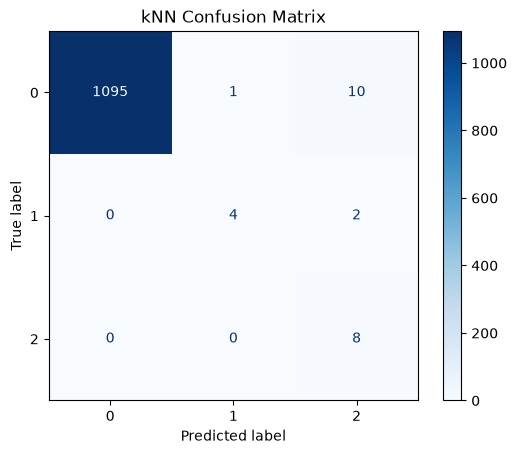

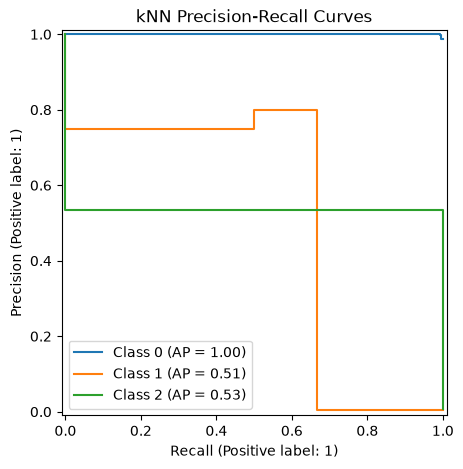


Random Forest — Macro-F1: 0.921
  Recall for class 0: 0.996
  Recall for class 1: 1.000
  Recall for class 2: 1.000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1106
           1       0.86      1.00      0.92         6
           2       0.73      1.00      0.84         8

    accuracy                           1.00      1120
   macro avg       0.86      1.00      0.92      1120
weighted avg       1.00      1.00      1.00      1120



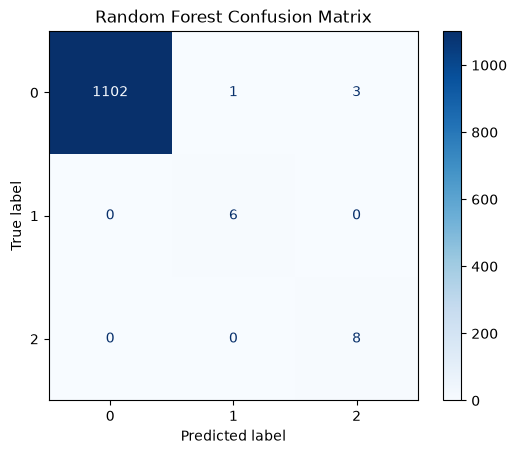

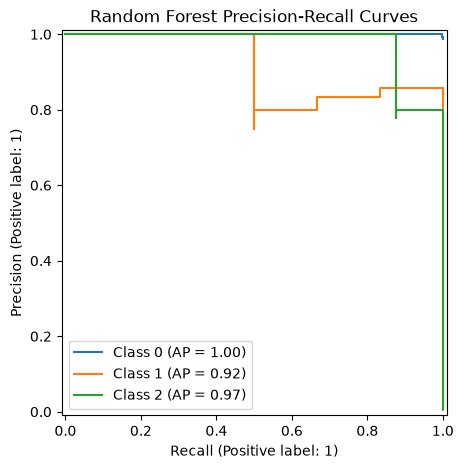


XGBoost — Macro-F1: 1.000
  Recall for class 0: 1.000
  Recall for class 1: 1.000
  Recall for class 2: 1.000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1106
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         8

    accuracy                           1.00      1120
   macro avg       1.00      1.00      1.00      1120
weighted avg       1.00      1.00      1.00      1120



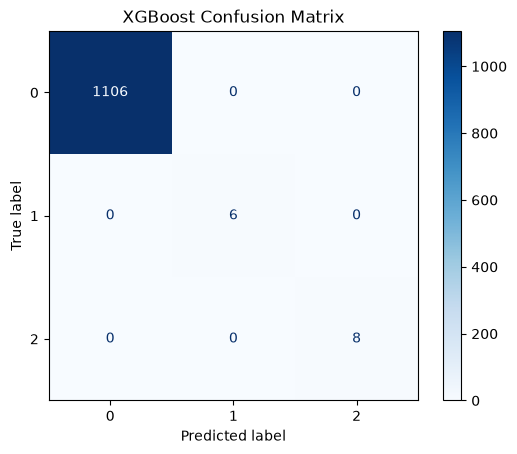

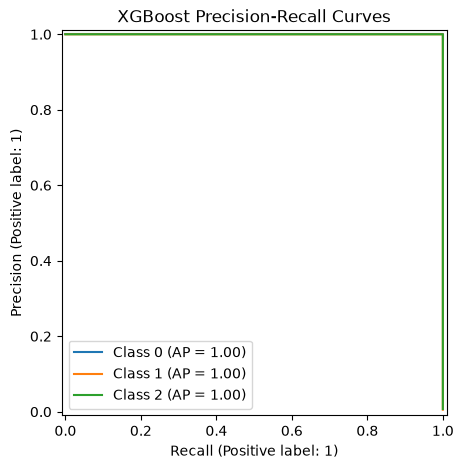


MLP — Macro-F1: 0.877
  Recall for class 0: 0.995
  Recall for class 1: 0.833
  Recall for class 2: 1.000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1106
           1       0.83      0.83      0.83         6
           2       0.67      1.00      0.80         8

    accuracy                           0.99      1120
   macro avg       0.83      0.94      0.88      1120
weighted avg       1.00      0.99      0.99      1120



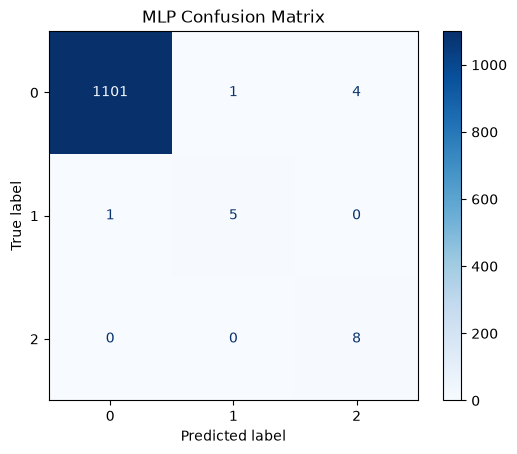

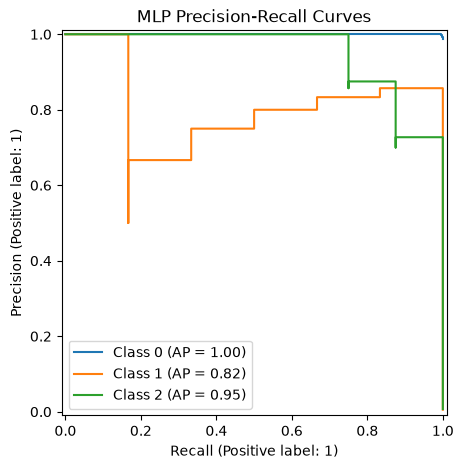


=== Summary (Macro-F1) ===
kNN: 0.765
Random Forest: 0.921
XGBoost: 1.000
MLP: 0.877


In [25]:
# Run evaluation for ALL FOUR MODELS
class_labels = sorted(y_test.unique())  # e.g. [0, 1, 2]

results = {}
results['kNN'] = evaluate_model(knn_best, X_test, y_test, 'kNN', class_labels)
results['Random Forest'] = evaluate_model(rf, X_test, y_test, 'Random Forest', class_labels)
results['XGBoost'] = evaluate_model(xgb, X_test, y_test, 'XGBoost', class_labels)
results['MLP'] = evaluate_model(mlp_best, X_test, y_test, 'MLP', class_labels)

print("\n=== Summary (Macro-F1) ===")
for name, score in results.items():
    print(f"{name}: {score:.3f}")

Here is how I would rank the classification methods:

1. XGBoost -> This is because it somehow did perfect. Of course, this is suspicous and we shall see if it works out in the application, but given the evaluation metrics, it did the best out of all the methods.

2. Random Forest -> This is because it got the second best score, did well classifying the minority classes and misfired on a few when they were supposed to be in the majority, which is better mistake than missing a minority data point.

3. MLP -> Had similar results to random forest, but missed a minority data point and a labeled a bit more of the majority data points as minority.

4. Knn -> This is because it didn't do well classifying the minority classes. It did particularly well with the majority class, but pretty bad with the other two (f1 score of 0.57 for class 2 and 0.73 for class 1, which isn't great for just a few datapoints with those classes). The precision-recall curves weren't great either for those classes.

<h1>F: Application </h1>

I must now classify: "A new planet is discovered around a nearby G-type star: Coruscant
b. It has the following properties: 0.95 Earth radii, 0.81 Earth masses, orbital
radius of 0.73 au (1.08x108 km)."

I will get the missing values by using an imputer that will fill in values based on similar data. For detection, I will put 'Other' because we don't truly know what identified the exoplanet.

In [ ]:
# Start with values given
example = {
    'P_MASS': 0.81,
    'P_RADIUS': 0.95,
    'P_SEMI_MAJOR_AXIS': 0.73,
    'P_TEMP_EQUIL': np.nan,
    'P_FLUX': np.nan,
    'P_PERIOD': np.nan,
    'S_TEMPERATURE': np.nan,
    'S_LUMINOSITY': np.nan,
    'S_HZ_OPT_MAX': np.nan,
    'S_HZ_OPT_MIN': np.nan,
    'S_HZ_CON_MAX': np.nan,
    'S_HZ_CON_MIN': np.nan,
}

# prepare detection feature (one-hot encoding)
example['DETECTION_Microlensing'] = 0
example['DETECTION_Other'] = 1
example['DETECTION_Radial Velocity'] = 0
example['DETECTION_Transit'] = 0 

new_point = pd.DataFrame([example])

cols = [
    'P_MASS',
    'P_RADIUS',
    'P_SEMI_MAJOR_AXIS',
    'P_TEMP_EQUIL',
    'P_FLUX',
    'P_PERIOD',
    'S_TEMPERATURE',
    'S_LUMINOSITY',
    'S_HZ_OPT_MAX',
    'S_HZ_OPT_MIN',
    'S_HZ_CON_MAX',
    'S_HZ_CON_MIN',
    'DETECTION_Microlensing',
    'DETECTION_Other',
    'DETECTION_Radial Velocity',
    'DETECTION_Transit'
]

# Impute using the SAME imputer fit on training data ---
new_point_imputed = pd.DataFrame(
    imputer.transform(new_point),
    columns=cols
)

# Overwrite values with what we were given since imputer would have guessed these as well
new_point_imputed['P_RADIUS'] = 0.95
new_point_imputed['P_MASS'] = 0.81
new_point_imputed['P_SEMI_MAJOR_AXIS'] = 0.73

# Re-apply log transform
log_cols = [
    'P_MASS', 
    'P_RADIUS', 
    'P_SEMI_MAJOR_AXIS', 
    'S_TEMPERATURE',
    'S_LUMINOSITY',
    'S_HZ_OPT_MIN', 
    'S_HZ_OPT_MAX', 
    'S_HZ_CON_MIN', 
    'S_HZ_CON_MAX',
    'P_TEMP_EQUIL', 
    'P_FLUX', 
    'P_PERIOD'
] 

for col in log_cols:
    new_point_imputed[f'{col}_LOG'] = np.log1p(new_point_imputed[col])

# Select only the columns the final X_train actually used
new_point_final = new_point_imputed[X_train.columns]

# Make Prediction
xgb_pred = xgb.predict(new_point_final)

if xgb == 0:
    prediction = "Not Habitable"
elif xgb == 1:
    prediction = "Likely Habitable"
else:
    prediction = "Optimistically Habitable"

print("Prediction: ", prediction)

Prediction:  Optimistically Habitable


The predition was "Optimistically Habitable". This makes sense since the radii, mass, and orbital distance showed it was close to Earth. Also, the filled-in data is statistically similar to exoplanets that were identified to this label.